In [1]:
import multiprocessing
import os
import re
import warnings
from copy import deepcopy
from itertools import combinations
from pathlib import Path

import anndata as ad
from adjustText import adjust_text
import gseapy as gp
import igraph
import leidenalg
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, zscore

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
## Input The Main Directory ##
main_directory = Path('/path/to/Jiang_etal_2026_HTAN')

In [3]:
output_dir = main_directory / "output"
output_dir.mkdir(parents=True, exist_ok=True)

input_dir = main_directory / "input"

processed_adata_dir = output_dir / "processed_adata"
processed_adata_dir.mkdir(parents=True, exist_ok=True)

adata_path = processed_adata_dir / "processed_adata.h5ad"

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

figures_extended_data_dir = figures_dir / "figures_extended_data"
figures_main_dir = figures_dir / "figures_main"

figures_extended_data_dir.mkdir(parents=True, exist_ok=True)
figures_main_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata1 = sc.read_h5ad(input_dir / 'Epithelial.h5ad')

# Preprocessing AnnData

## Filter for Paired Samples

In [5]:
adata1.obs["Patient"] = (
    adata1.obs["Sample ID"]
    .str.replace(r"[A-Za-z]+[0-2]*$", "", regex=True)
    .astype("string")
)

In [6]:
samples = pd.Index(sorted(set(adata1.obs.loc[:,'Sample ID'].cat.categories)))

In [7]:
tally_df = pd.DataFrame({'Sample': samples})

In [8]:
tally_df.loc[:,'Patient'] = samples.str.replace('[A-Za-z]+[0-2]*$','', regex = True) 

In [9]:
tally_df.loc[:,'Site'] = 'N'

In [10]:
for x, i, j in zip(np.arange(tally_df.shape[0]), tally_df.Sample, tally_df.Patient):
    tally_df.loc[x, "Site"] = re.sub(r"[0-9]", "", re.sub(j, "", i))

In [11]:
tally_df = tally_df.groupby(['Patient','Site']).size().unstack().fillna(0)

In [12]:
ind1 = tally_df.M > 0
ind2 = tally_df.P > 0
paired_patients = tally_df.index[ind1 & ind2]

In [13]:
adata = adata1[adata1.obs.Patient.isin(paired_patients),:].copy()

## Hotspot Module 29 (Tumor ISC-like) Score

In [14]:
ISC_module29 = [
'AREG',
'EREG',
'DPEP1',
'ASCL2',
'GZMB',
'KRT23',
'IGF2',
'CCND1',
'CTNNBL1',
'PTPRO',
'APOLD1',
'SMOC2',
'LGR5',
'RGMB',
'HES1',
'ZFP36L2',
'SOX9',
'ZFP36L1',
'ERBB3',
'KDM5A',
'CDH1',
'REST',
'SLC11A2',
'GRB7',
'PGAP3',
'ERBB2',
'STARD3',
'MED1',
'FBXL20',
'CDK12',
'MIEN1',
'SLC38A11',
'COL2A1',
'LINC00950',
'NRN1',
'MROH8',
'CNNM1',
'RP11-25E2.1',
'RP1-23E21.2',
'NBAS',
'PIGN',
'TANGO6',
'AGER',
'LA16C-431H6.6',
'RP11-473M20.16',
'TYW5',
'FLT3LG',
'PABPN1',
'ATF2',
'CCDC27',
'FRRS1L',
'LA16C-380H5.6',
'LINC01521',
'RP4-550H1.5',
]

In [15]:
imp_df = pd.DataFrame(adata.layers['imputed'], index=adata.obs.index, columns=adata.var_names)

In [16]:
adata_tmp = sc.AnnData(imp_df)

In [17]:
sc.tl.score_genes(adata_tmp, gene_list = ISC_module29, score_name = 'ISC_module29')

In [18]:
adata.obs.loc[:,'ISC_module29'] = zscore(adata_tmp.obs.ISC_module29)

In [19]:
adata.obs.loc[:,'ZFP36L2_imputed'] = imp_df.loc[adata.obs.index, 'ZFP36L2']

In [20]:
adata.obs.loc[:,'Cell Type2'] = adata.obs.loc[:,'Cell Type'].astype(str)
ind = ~adata.obs.loc[:,'Cell Type2'].isin(['Primary Tumor','Metastasis'])
adata.obs.loc[ind,'Cell Type2'] = 'Normal'

### Identify ISC-like Tumor Cells

In [21]:
ind2 = adata.obs.loc[:,'Cell Type2'].isin(['Primary Tumor','Metastasis'])

In [22]:
adata3 = adata[ind2,:]

In [23]:
mat = pd.DataFrame(adata3.raw.X.todense(), 
                   index=adata3.raw.obs_names,
                   columns = adata3.raw.var_names)
mat = mat.loc[:,adata3.var_names]

In [24]:
adata4 = sc.AnnData(mat)

In [25]:
adata4.obs = adata3.obs.copy()

In [26]:
adata4.raw = adata4

In [27]:
sc.pp.normalize_total(adata4)
sc.pp.log1p(adata4)

In [28]:
sc.pp.highly_variable_genes(adata4, n_top_genes = 3000)
sc.tl.pca(adata4, mask_var="highly_variable", random_state=0)
sc.pp.neighbors(adata4, n_neighbors=20)

In [29]:
sc.tl.leiden(
    adata4,
    flavor="leidenalg"
)

In [30]:
sc.tl.umap(adata4, random_state=0)

In [31]:
adata4.obs.loc[:,'ZFP36L2_imputed'] = imp_df.loc[adata4.obs.index, 'ZFP36L2'] 

In [32]:
obs_df = adata4.obs.loc[:,['leiden', 'ISC_module29', 'ISC Signature','Module 29 Score','ZFP36L2_imputed']]

In [33]:
isc_df = obs_df.groupby('leiden').median(['ISC_module29','ISC Signature','Module 29 Score','ZFP36L2_imputed'])

In [34]:
isc_df = isc_df.sort_values('ISC_module29')

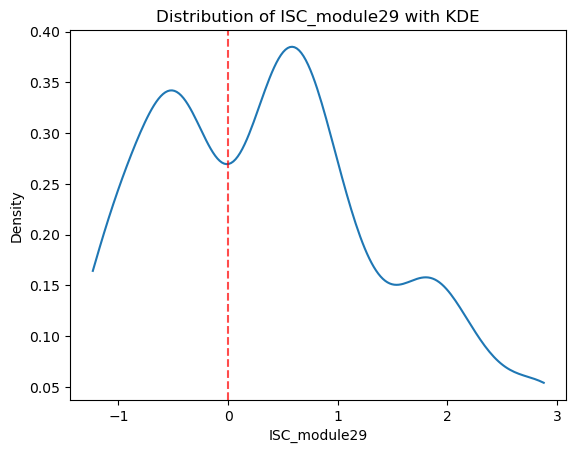

In [35]:
sns.kdeplot(isc_df.ISC_module29, bw_adjust=0.55, cut=0)

plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.title("Distribution of ISC_module29 with KDE")
plt.show()

In [36]:
# Bimodality at 0, set for ISC-like threshold
thr = 0

In [37]:
isc_clusters = isc_df.index[isc_df.loc[:,'ISC_module29'] > thr]

In [38]:
adata4.obs.loc[:,'ISC-like'] = adata4.obs.leiden.isin(isc_clusters).astype('category')

In [39]:
adata4.obs.loc[:,'ISC-like'] = np.array(['Not ISC-like','ISC-like'])[1*adata4.obs.loc[:,'ISC-like'].astype(bool)]

In [40]:
adata.obs.loc[:,'ISC-like'] = 'Not ISC-like' 
ind = adata.obs.loc[:,'Cell Type'].astype(str) == 'ISC'
adata.obs.loc[ind, 'ISC-like'] = 'ISC-like'

In [41]:
adata.obs.loc[adata4.obs.index,'ISC-like'] = adata4.obs.loc[:,'ISC-like']

### Save Processed AnnData

In [42]:
adata.write_h5ad(adata_path)

# ZFP36L2 Expression and ISC-like Score Violin Plots

In [43]:
plot_df_cell = adata.obs.loc[:,['Sample ID','Cell Type','ISC-like','ISC_module29']]
plot_df_cell.loc[:,'ZFP36L2'] = adata.layers['imputed'][:,adata.var_names=='ZFP36L2']

In [44]:
def categorize_cell_type(cell_type):
    if 'Precursor' in cell_type:
        return 'Transit-Amplifying'
    elif cell_type in ['Primary Tumor', 'Metastasis', 'ISC']:
        return cell_type
    else:
        return 'Differentiated'

plot_df_cell['Cell Type 2'] = plot_df_cell['Cell Type'].apply(categorize_cell_type)

In [45]:
plot_df_cell['Cell Type 3'] = plot_df_cell['Cell Type 2'].replace({
    'Transit-Amplifying': 'Transit-Amplifying/ISC',
    'ISC': 'Transit-Amplifying/ISC'
})

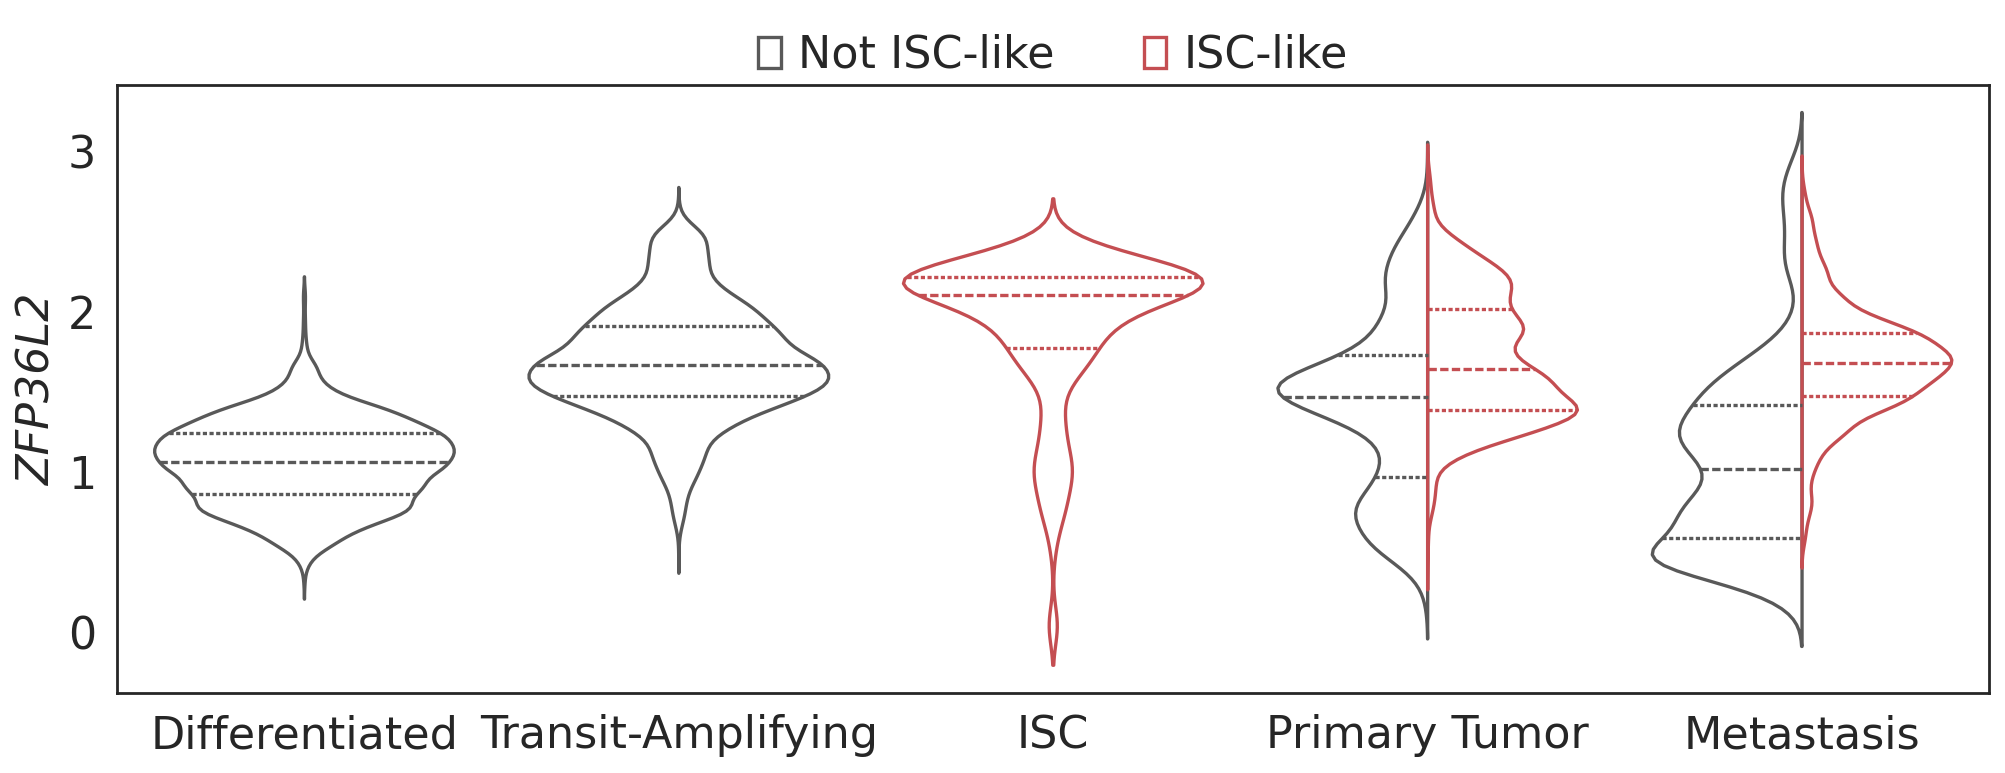

In [46]:
figures_extended_data_1a = figures_extended_data_dir / "figure_1a"
figures_extended_data_1a.mkdir(parents=True, exist_ok=True)

sc.set_figure_params(fontsize=30)
sns.set_theme(style="white")

x_order = ['Differentiated', 'Transit-Amplifying', 'ISC', 'Primary Tumor', 'Metastasis']

fig, ax = plt.subplots(figsize=(15, 5))

def should_split(cell_type):
    return cell_type in ['Primary Tumor', 'Metastasis']

for cell_type in x_order:
    subset = plot_df_cell[plot_df_cell['Cell Type 2'] == cell_type]
    split_violin = should_split(cell_type)
    
    sns.violinplot(
        data=subset,
        x='Cell Type 2',
        y='ZFP36L2',
        hue='ISC-like',
        split=split_violin,
        inner="quart",
        fill=False,
        palette={"Not ISC-like": ".35", "ISC-like": "r"},
        hue_order=["Not ISC-like", "ISC-like"],
        ax=ax,
        order=[cell_type],
    )

ax.set_xlabel('')
font = font_manager.FontProperties(style='italic', size=20)
ax.set_ylabel("ZFP36L2", fontproperties=font)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(
    unique_labels.values(),
    unique_labels.keys(),
    bbox_to_anchor=(0.5, 1.15),
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=20
)

plt.savefig(figures_extended_data_1a / "ZFP36L2_violinplot.pdf", format="pdf", bbox_inches="tight")

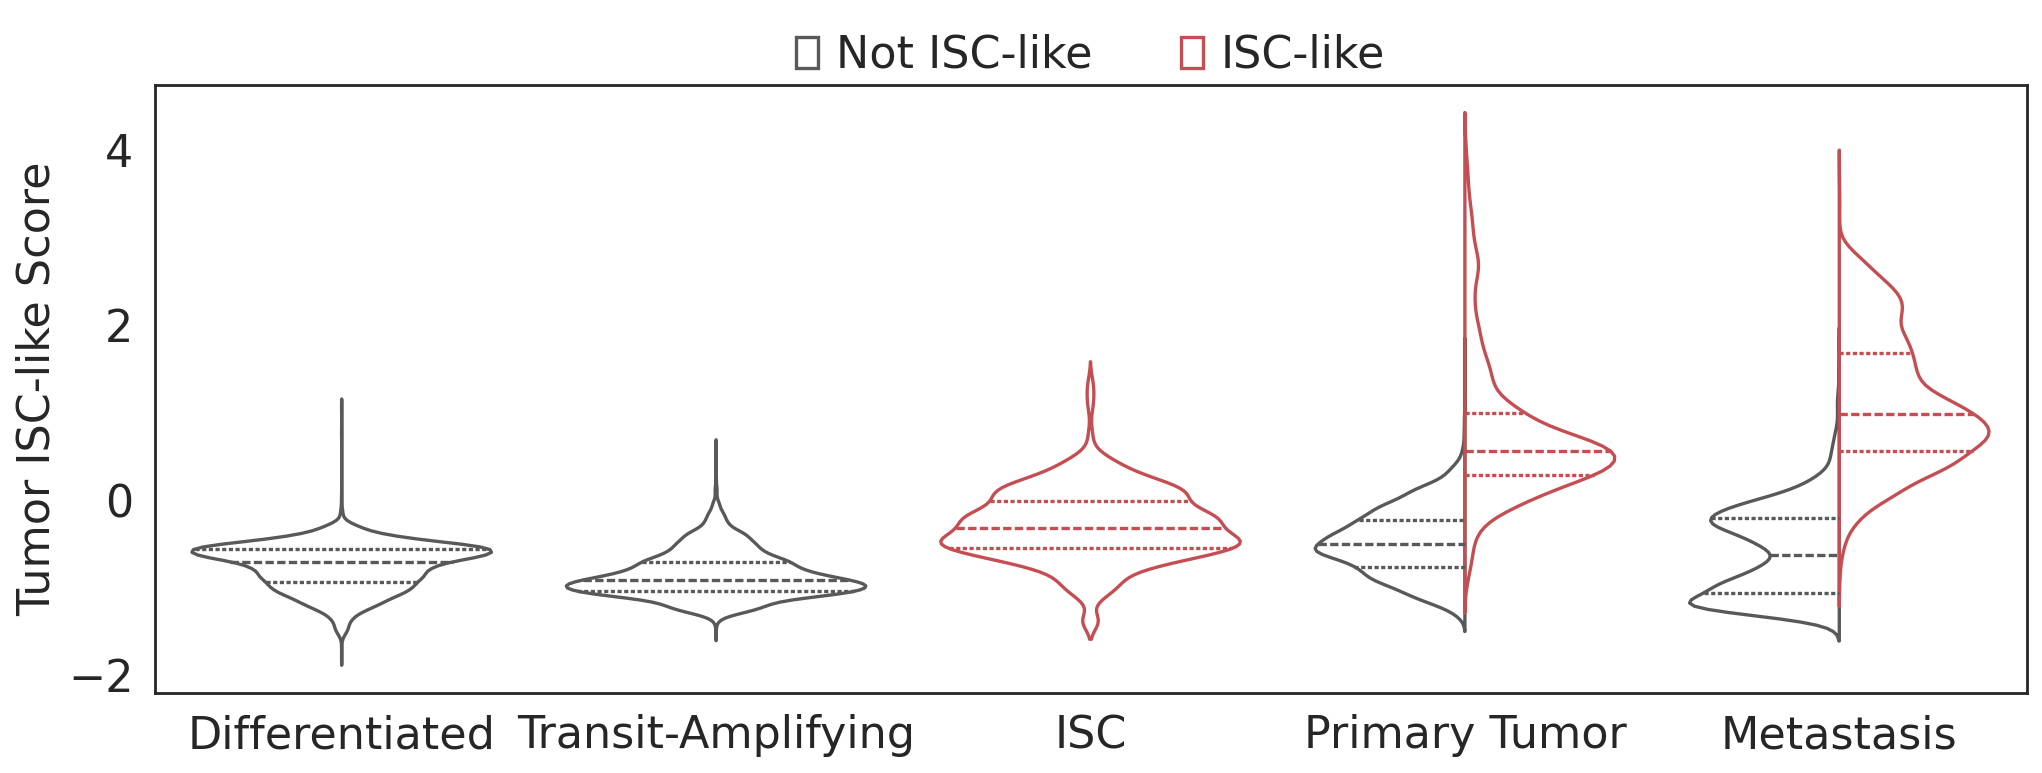

In [47]:
sc.set_figure_params(fontsize=30)
sns.set_theme(style="white")

x_order = ['Differentiated', 'Transit-Amplifying', 'ISC', 'Primary Tumor', 'Metastasis']

fig, ax = plt.subplots(figsize=(15, 5))

for cell_type in x_order:
    subset = plot_df_cell[plot_df_cell['Cell Type 2'] == cell_type]
    split_violin = should_split(cell_type)
    
    sns.violinplot(
        data=subset,
        x='Cell Type 2',
        y='ISC_module29',
        hue='ISC-like',
        split=split_violin,
        inner="quart",
        fill=False,
        palette={"Not ISC-like": ".35", "ISC-like": "r"},
        hue_order=["Not ISC-like", "ISC-like"],
        ax=ax,
        order=[cell_type],
    )

ax.set_xlabel('')
ax.set_ylabel('Tumor ISC-like Score', fontsize=20)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(
    unique_labels.values(),
    unique_labels.keys(),
    bbox_to_anchor=(0.5, 1.15),
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=20
)

plt.savefig(figures_extended_data_1a / "tumor_isclike_violinplot.pdf", format="pdf", bbox_inches="tight")

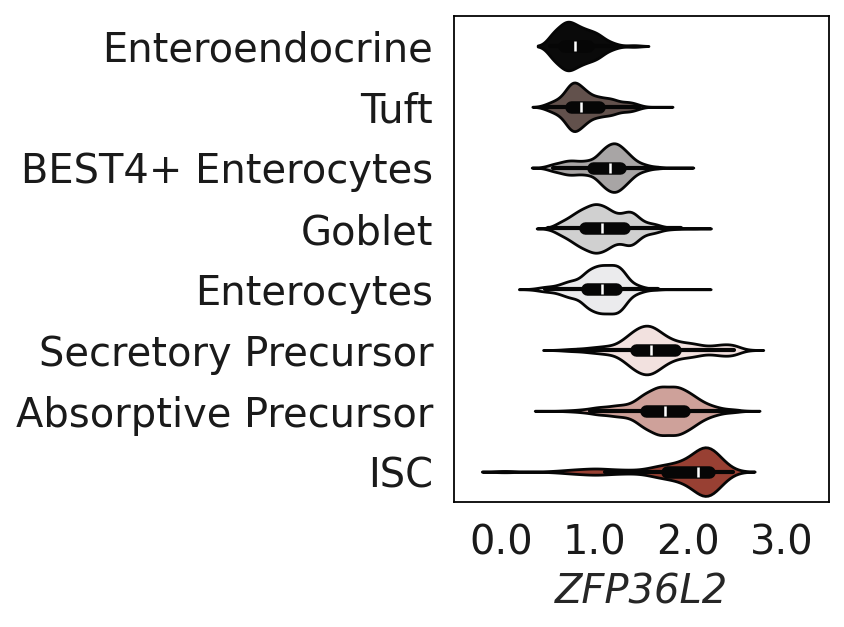

In [48]:
figures_extended_data_1c = figures_extended_data_dir / "figure_1c"
figures_extended_data_1c.mkdir(parents=True, exist_ok=True)

sc.set_figure_params(fontsize=18)
fig, ax = plt.subplots(figsize=(3, 4))  

x_order = [
    'ISC', 'Absorptive Precursor', 'Secretory Precursor',
    'Enterocytes', 'Goblet', 'BEST4+ Enterocytes',
    'Tuft', 'Enteroendocrine'
]
x_order.reverse()

colormap = {
    'ISC': '#A93322',
    'Absorptive Precursor': '#d69b92',
    'Secretory Precursor': '#f5dedc',
    'Enteroendocrine': '#0a0a0a',
    'Tuft': '#664f48',
    'Enterocytes': '#ebebed',
    'Goblet': '#d0d0d0',
    'BEST4+ Enterocytes': '#a8a5a5'
}

sns.violinplot(
    data=plot_df_cell,
    y='Cell Type',
    x='ZFP36L2',
    ax=ax,
    density_norm='width',
    order=x_order,
    palette=colormap
)

# --- axis limits ---
x_min = -0.5
x_max = 3.5
ax.set_xlim(x_min, x_max)

tick_spacing = 0.5
x_ticks = [tick for tick in range(int(x_min), int(x_max) + 1)
           if (tick - x_min) % tick_spacing == 0]
x_tick_labels = [f'{val:.1f}' for val in x_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels)

italic_font = font_manager.FontProperties(style='italic', size=18)
ax.set_xlabel("ZFP36L2", fontproperties=italic_font)
ax.set_ylabel("")

ax.grid(False)

plt.savefig(figures_extended_data_1c / "ZFP36L2_violinplot_AllNormalCellTypes.pdf", format="pdf", bbox_inches="tight")

## Statistics

### Tumor ISC-like Split Violin Plot

In [49]:
cell_type_isc_like_values = []
isc_module29_values = []

unique_combinations = plot_df_cell[['Cell Type 2', 'ISC-like']].drop_duplicates()
for _, row in unique_combinations.iterrows():
    cell_type = row['Cell Type 2']
    isc_like = row['ISC-like']
    
    filtered_rows = plot_df_cell[(plot_df_cell['Cell Type 2'] == cell_type) & (plot_df_cell['ISC-like'] == isc_like)]
    
    isc_module29_values.extend(filtered_rows['ISC_module29'].tolist())
    
    cell_type_isc_like_str = f"{cell_type} - {isc_like}"
    
    cell_type_isc_like_values.extend([cell_type_isc_like_str] * len(filtered_rows))
 
result_df = pd.DataFrame({'Cell Type/ISC-like': cell_type_isc_like_values, 'ISC_module29': isc_module29_values})

In [50]:
group1_list_ISC = []
group2_list_ISC = []
p_value_list_ISC = []
group1_isc_values = []
group2_isc_values = []

unique_combinations = result_df['Cell Type/ISC-like'].unique()

for group1, group2 in combinations(unique_combinations, 2):
    group1_values = result_df[result_df['Cell Type/ISC-like'] == group1]['ISC_module29']
    group2_values = result_df[result_df['Cell Type/ISC-like'] == group2]['ISC_module29']
    
    if len(group1_values) > 0 and len(group2_values) > 0:
        stat, p_value = mannwhitneyu(group1_values, group2_values)

        group1_list_ISC.append(group1)
        group2_list_ISC.append(group2)
        p_value_list_ISC.append(p_value)

        group1_isc_values.append(group1_values.mean())  #can use `.median()` instead
        group2_isc_values.append(group2_values.mean())

mannwhitney_df_ISC = pd.DataFrame({
    'Group 1': group1_list_ISC,
    'Group 2': group2_list_ISC,
    'p-value': p_value_list_ISC,
    'Group 1 Mean ISC_module29': group1_isc_values,
    'Group 2 Mean ISC_module29': group2_isc_values
})

mannwhitney_df_ISC['p-value <0.05'] = ['significant' if p_val < 0.05 else '' for p_val in mannwhitney_df_ISC['p-value']]

bonferroni_factor = len(mannwhitney_df_ISC)  
mannwhitney_df_ISC['Bonferroni correction'] = mannwhitney_df_ISC['p-value'] * bonferroni_factor

mannwhitney_df_ISC['Bonferroni correction'] = mannwhitney_df_ISC['Bonferroni correction'].apply(lambda x: min(x, 1.0))

mannwhitney_df_ISC['q-value <0.05'] = mannwhitney_df_ISC['Bonferroni correction'].apply(lambda x: 'significant' if x < 0.05 else '')

In [51]:
mannwhitney_df_ISC.to_csv(figures_extended_data_1a / "mannwhitney_results_tumorisclike_violin.csv", index=False)

### ZFP36L2 Expression Split Violin Plot

In [52]:
cell_type_isc_like_values_zfp = []
zfp_values = []

unique_combinations = plot_df_cell[['Cell Type 2', 'ISC-like']].drop_duplicates()
for _, row in unique_combinations.iterrows():
    cell_type = row['Cell Type 2']
    isc_like = row['ISC-like']
    
    filtered_rows = plot_df_cell[(plot_df_cell['Cell Type 2'] == cell_type) & (plot_df_cell['ISC-like'] == isc_like)]
    
    zfp_values.extend(filtered_rows['ZFP36L2'].tolist())
    
    cell_type_isc_like_str = f"{cell_type} - {isc_like}"
    
    cell_type_isc_like_values_zfp.extend([cell_type_isc_like_str] * len(filtered_rows))
 
result_df_zfp = pd.DataFrame({'Cell Type/ISC-like': cell_type_isc_like_values_zfp, 'ZFP36L2': zfp_values})

In [53]:
group1_list_zfp = []
group2_list_zfp = []
p_value_list_zfp = []
group1_mean_zfp = [] 
group2_mean_zfp = [] 

unique_combinations_zfp = result_df_zfp['Cell Type/ISC-like'].unique()

for group1, group2 in combinations(unique_combinations_zfp, 2):
    group1_values = result_df_zfp[result_df_zfp['Cell Type/ISC-like'] == group1]['ZFP36L2']
    group2_values = result_df_zfp[result_df_zfp['Cell Type/ISC-like'] == group2]['ZFP36L2']
    
    if len(group1_values) > 0 and len(group2_values) > 0:
        stat, p_value = mannwhitneyu(group1_values, group2_values)

        group1_list_zfp.append(group1)
        group2_list_zfp.append(group2)
        p_value_list_zfp.append(p_value)

        group1_mean_zfp.append(group1_values.mean())  #can use .median() 
        group2_mean_zfp.append(group2_values.mean())

mannwhitney_df_zfp = pd.DataFrame({
    'Group 1': group1_list_zfp,
    'Group 2': group2_list_zfp,
    'p-value': p_value_list_zfp,
    'Group 1 Mean ZFP36L2': group1_mean_zfp,
    'Group 2 Mean ZFP36L2': group2_mean_zfp
})

mannwhitney_df_zfp['p-value <0.05'] = ['significant' if p_val < 0.05 else '' for p_val in mannwhitney_df_zfp['p-value']]

bonferroni_factor = len(mannwhitney_df_zfp)  
mannwhitney_df_zfp['Bonferroni correction'] = mannwhitney_df_zfp['p-value'] * bonferroni_factor

#ensure values do not exceed 1.0
mannwhitney_df_zfp['Bonferroni correction'] = mannwhitney_df_zfp['Bonferroni correction'].apply(lambda x: min(x, 1.0))

mannwhitney_df_zfp['q-value <0.05'] = mannwhitney_df_zfp['Bonferroni correction'].apply(lambda x: 'significant' if x < 0.05 else '')

In [54]:
mannwhitney_df_zfp.to_csv(figures_extended_data_1a / "mannwhitney_results_ZFP_isclike_violin.csv", index=False)

# FDLs

## Normal Cell Types

In [55]:
adata_norm = adata[~adata.obs['Cell Type'].isin(['Primary Tumor', 'Metastasis'])].copy()

sc.tl.pca(adata_norm, mask_var='highly_variable', random_state=0)
sc.pp.neighbors(adata_norm, n_neighbors=20, use_rep='X_pca', n_pcs=30) 
sc.tl.draw_graph(adata_norm, layout='fa', random_state=0) 

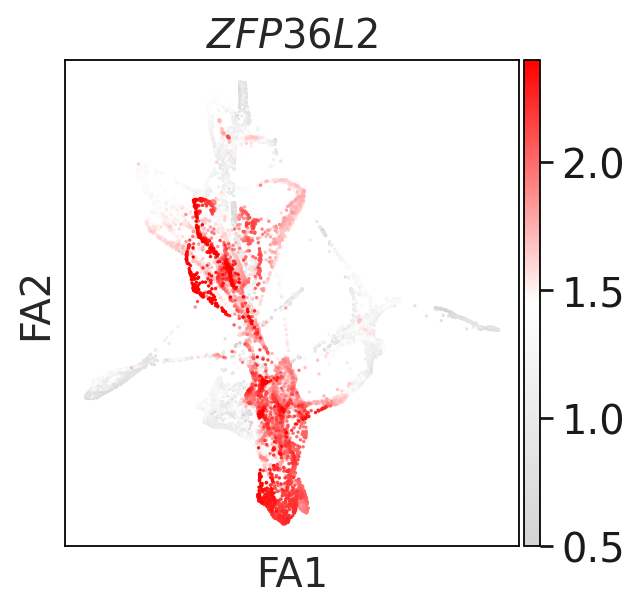

In [56]:
figures_extended_data_1b = figures_extended_data_dir / "figure_1b"
figures_extended_data_1b.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = figures_extended_data_1b

cmap = mcolors.LinearSegmentedColormap.from_list(
    'red_to_blue', ['lightgrey','white', 'red'], N=256
)

X = adata_norm.obsm["X_draw_graph_fa"].copy()
adata_norm.obsm["X_draw_graph_fa"] = np.column_stack((X[:, 1], -X[:, 0]))

sc.pl.draw_graph(adata_norm, color='ZFP36L2_imputed', cmap=cmap, vmin=0.5, vmax=2.4, title=r"$\it{ZFP36L2}$", save = '_ZFP36L2_expression.pdf')

plt.show()

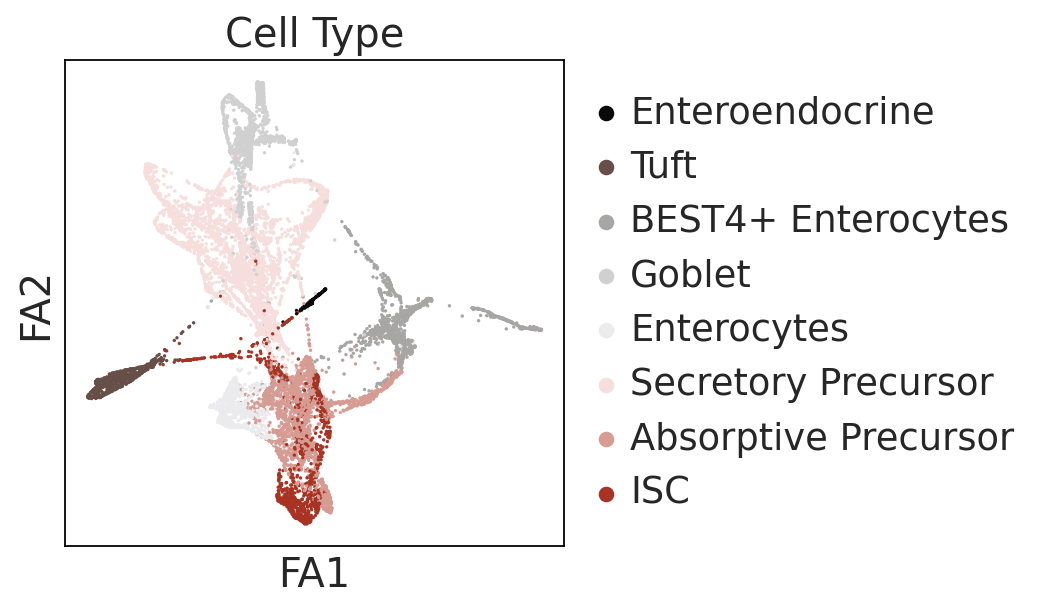

In [57]:
colormap = {
    'ISC': '#A93322',  
    'Absorptive Precursor': '#d69b92',  
    'Secretory Precursor': '#f5dedc',  
    'Enteroendocrine': '#0a0a0a',  
    'Tuft': '#664f48', 
    'Enterocytes': '#ebebed',  
    'Goblet': '#d0d0d0',  
    'BEST4+ Enterocytes': '#a8a5a5'  
}

sc.pl.draw_graph(adata_norm, color = 'Cell Type', palette = colormap, save = '_NormalCellTypes.pdf')
sc.settings.figdir = "./figures"

# DEGs Across Normal and Tumor ISC-like Populations

In [58]:
def update_cell_type(cell_type):
    if cell_type in ['Primary Tumor', 'Metastasis']:
        return 'Tumor'
    elif cell_type.endswith('Precursor'):
        return 'Transit-Amplifying'
    elif cell_type == 'ISC':
        return 'ISC'
    else:
        return 'Differentiated'

adata.obs['Cell Type 2'] = adata.obs['Cell Type'].apply(update_cell_type)

In [59]:
adata.obs['DEG'] = adata.obs['Cell Type 2']

adata.obs['ISC-like'] = adata.obs['ISC-like'].astype(str)

adata.obs.loc[adata.obs['Cell Type 2'] == 'Tumor', 'DEG'] += ' ' + adata.obs['ISC-like']

In [60]:
sc.tl.rank_genes_groups(adata, groupby='DEG', method='wilcoxon', layer='log', use_raw=False, key_added = 'DEG_all_tumorisclike')

In [61]:
to_plot_module29 = {'Tumor ISC-Like Module 29': ISC_module29}

In [62]:
isc_adata = adata[adata.obs["Cell Type"] == "ISC"]

imputed_expression = {}
for gene in ISC_module29:
    if gene in isc_adata.var_names:
        imputed_counts = isc_adata[:, gene].layers['imputed'].A.flatten() if hasattr(isc_adata.layers['imputed'], 'A') else isc_adata[:, gene].layers['imputed'].flatten()
        imputed_expression[gene] = imputed_counts.mean()
    else:
        print(f"Warning: Gene {gene} not found in `adata.var_names`.")

df_expression = pd.DataFrame.from_dict(imputed_expression, orient="index", columns=["Mean Imputed Expression"])
df_expression = df_expression.sort_values(by="Mean Imputed Expression", ascending=False)

In [63]:
figures_main_data_1b = figures_main_dir / "figure_1b"
figures_main_data_1b.mkdir(parents=True, exist_ok=True)
df_expression.to_csv(figures_main_data_1b/"Module_29_genes_expression_ISC_cells.csv")

In [64]:
sc.set_figure_params(fontsize=17)

categories_order = ['ISC', 'Transit-Amplifying', 'Tumor ISC-like', 'Differentiated', 'Tumor Not ISC-like']

key = "DEG_all_tumorisclike"
groupby = "DEG"
pvals_adj = adata.uns[key]['pvals_adj']
gene_names = adata.uns[key]['names']

filtered_genes = []

for group in categories_order:
    if group in pvals_adj.dtype.names:
        pvals = pvals_adj[group]
        genes = gene_names[group]
        filtered_genes.extend([gene for gene, pval in zip(genes, pvals) if pval < 0.05])

filtered_genes = list(dict.fromkeys(filtered_genes))

filtered_module_genes = [gene for gene in to_plot_module29['Tumor ISC-Like Module 29'] if gene in filtered_genes]

isc_mean_expression_imputed = np.asarray(
    adata[adata.obs[groupby] == 'ISC'][:, filtered_module_genes].layers["imputed"].mean(axis=0)
).flatten()

sorted_indices_imputed = np.argsort(isc_mean_expression_imputed)[::-1]
sorted_genes_hm_imputed = [filtered_module_genes[i] for i in sorted_indices_imputed]

## Sort on Decreasing Gene Expression within ISCs

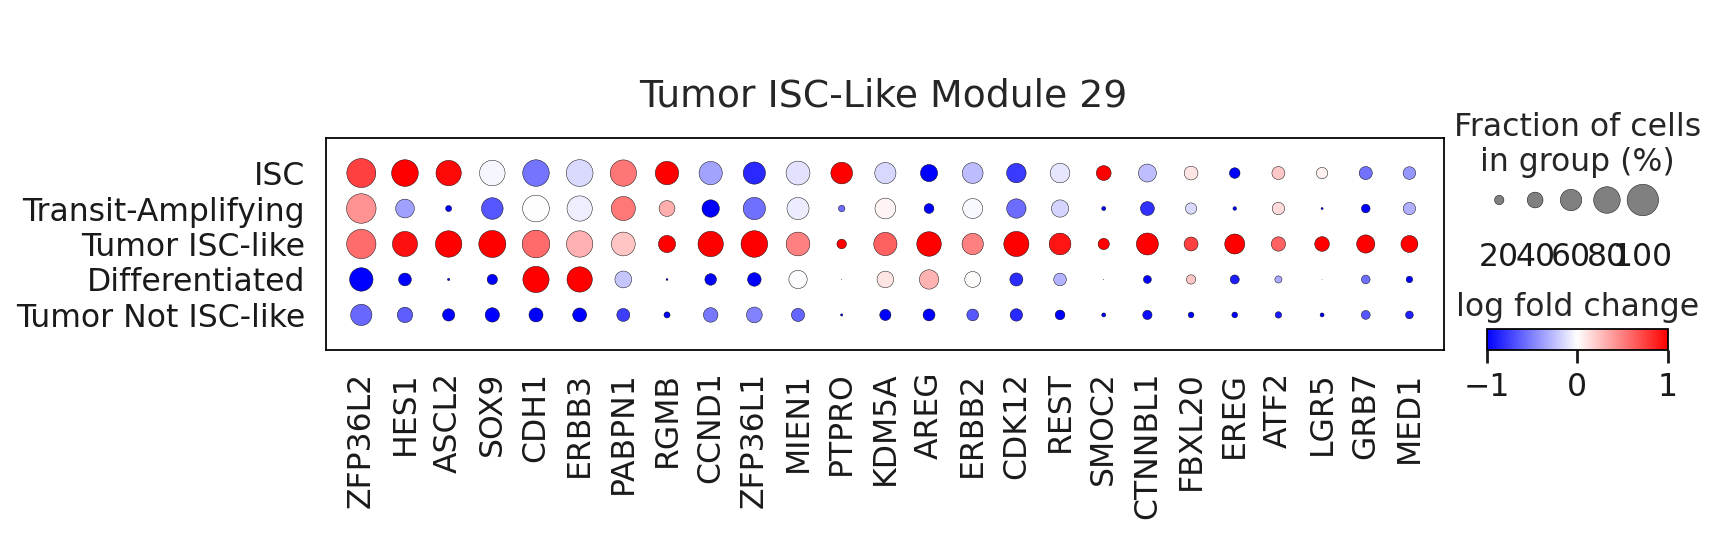

In [65]:
sc.set_figure_params(fontsize=17)

categories_order = ['ISC', 'Transit-Amplifying', 'Tumor ISC-like', 'Differentiated', 'Tumor Not ISC-like']

key = "DEG_all_tumorisclike"
groupby = "DEG"
pvals_adj = adata.uns[key]['pvals_adj']
gene_names = adata.uns[key]['names']

filtered_genes = []

for group in categories_order:
    if group in pvals_adj.dtype.names:
        pvals = pvals_adj[group]
        genes = gene_names[group]
        filtered_genes.extend([gene for gene, pval in zip(genes, pvals) if pval < 1e-100])

filtered_genes = list(dict.fromkeys(filtered_genes))

to_plot_module29 = {'Tumor ISC-Like Module 29': ISC_module29}

filtered_module_genes = [gene for gene in to_plot_module29['Tumor ISC-Like Module 29'] if gene in filtered_genes]

top25_genes = sorted_genes_hm_imputed[:25]

sc.pl.rank_genes_groups_dotplot(
    adata,
    key=key,
    groupby=groupby,
    var_names=top25_genes,
    vmin=-1,
    vmax=1,
    values_to_plot='logfoldchanges',
    var_group_positions=[(0, len(top25_genes)-1)],
    var_group_labels=['Tumor ISC-Like Module 29'],
    categories_order=categories_order,
    cmap='bwr',
    var_group_rotation=0,
    dendrogram=False,
    show=False
)

plt.savefig(
    figures_main_data_1b / "Module29_ranked_gene_expression_dotplot_all_celltypes.pdf",
    bbox_inches='tight'
)  

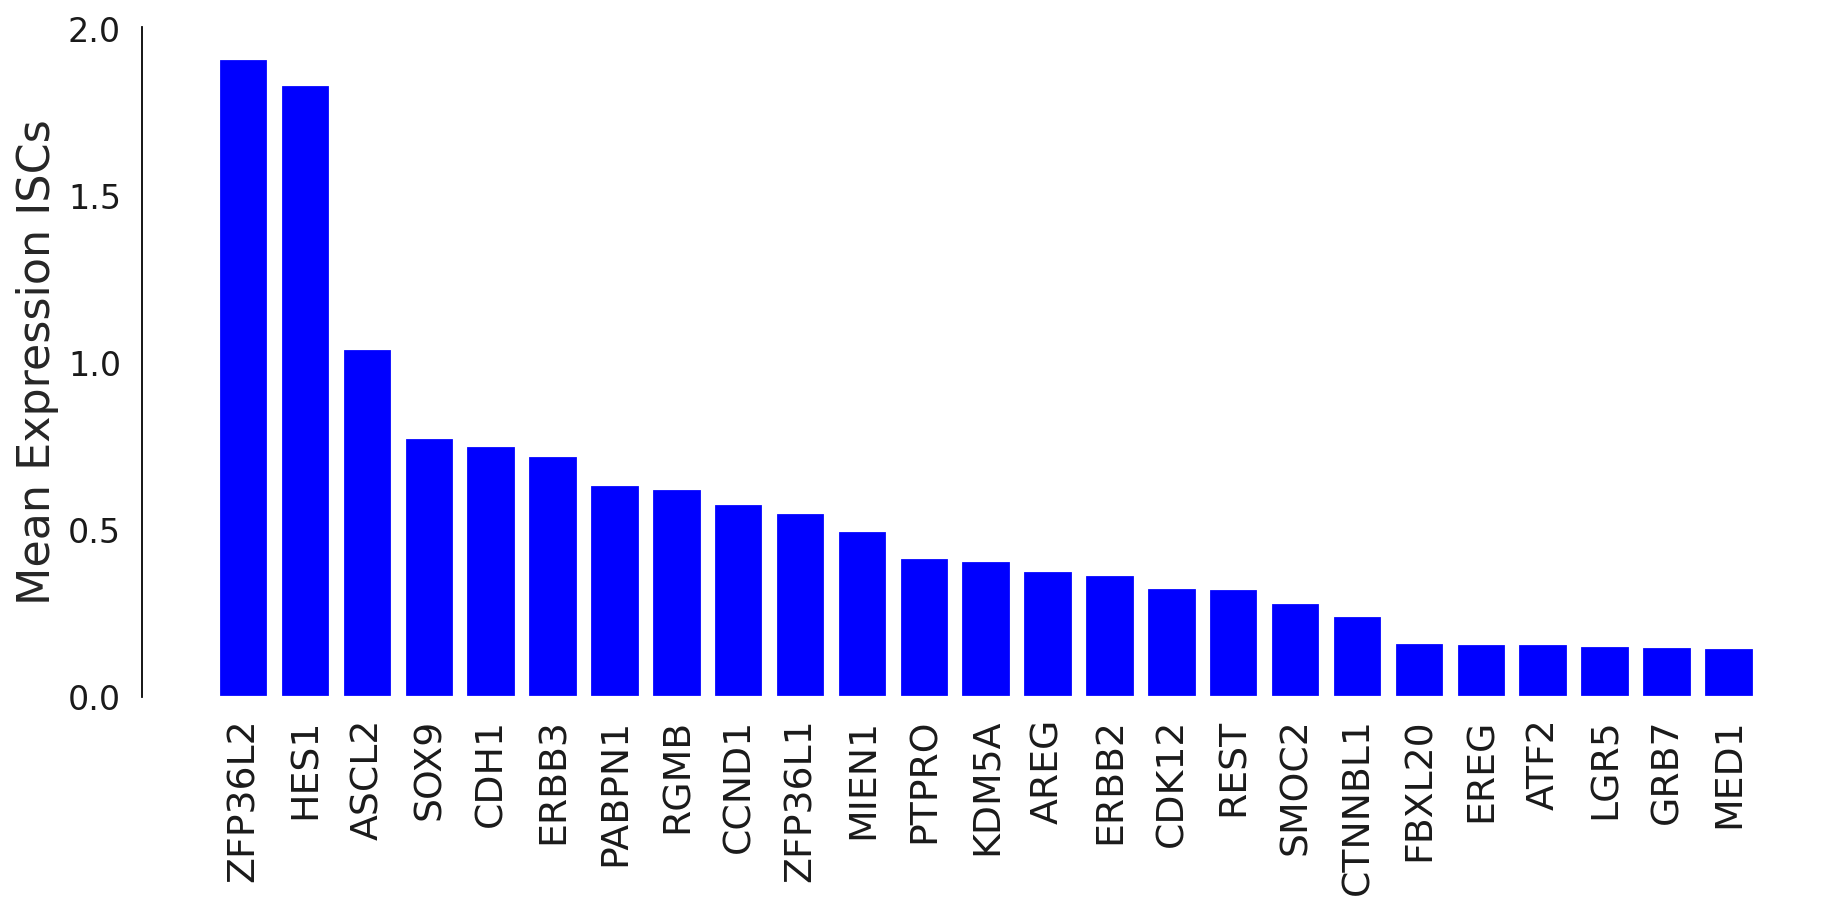

In [66]:
df_expression_plot = df_expression.loc[sorted_genes_hm_imputed[:25]]

plt.figure(figsize=(12, 6))
plt.bar(df_expression_plot.index, df_expression_plot['Mean Imputed Expression'], color='blue', width=0.8)

plt.xlabel('')
plt.ylabel('Mean Expression ISCs', fontsize=20)

plt.xticks(rotation=90, ha='center')
plt.yticks(fontsize=15)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.grid(False)

plt.tight_layout()
plt.savefig(figures_main_data_1b / "ISC_module29_mean_expression_barplot_ISC_cells.pdf", bbox_inches='tight')

plt.show()

# AP1 Gene Set Expression Across ZFP36L2 High and Low Cell Populations

## AP1 Gene Set Score Violin Plots

In [67]:
adata.obs.loc[:, 'ZFP36L2'] = imp_df.loc[adata.obs.index, 'ZFP36L2']

In [68]:
gmt_file = input_dir / "pathways_for_gsea.gmt"

genes_for_pid_ap1_pathway = []

with open(gmt_file, "r") as file:
    for line in file:
        parts = line.strip().split("\t")
        if parts[0] == "PID_AP1_PATHWAY":
            genes_for_pid_ap1_pathway = parts[2:]
            break

genes_for_pid_ap1_pathway = [
    gene for gene in genes_for_pid_ap1_pathway
    if gene in adata.var_names
]

score_name = "PID_AP1_PATHWAY_autocorr_score"

In [69]:
sc.tl.score_genes(adata, gene_list=genes_for_pid_ap1_pathway, score_name=score_name)

adata.obs['PID_AP1'] = zscore(adata.obs[score_name])

In [70]:
def update_cell_type(cell_type):
    if cell_type.endswith('Precursor'):
        return 'Transit-Amplifying'
    elif cell_type == 'ISC':
        return 'ISC'
    elif cell_type in ['Primary Tumor', 'Metastasis']:
        return cell_type  
    else:
        return 'Differentiated'

adata.obs['DEG'] = adata.obs['Cell Type'].apply(update_cell_type)

adata.obs['DEG_ZFP_expression'] = np.nan

for cell_type in adata.obs['DEG'].unique():
    cell_type_idx = adata.obs['DEG'] == cell_type
    
    expression_values = adata[cell_type_idx, :].X[:, adata.var_names == 'ZFP36L2'].toarray().flatten()
    
    lower_bound = np.percentile(expression_values, 10)
    upper_bound = np.percentile(expression_values, 90)
    
    high_expression_mask = expression_values >= upper_bound
    low_expression_mask = expression_values <= lower_bound
    
    adata.obs.loc[cell_type_idx[cell_type_idx].index[high_expression_mask], 'DEG_ZFP_expression'] = 'ZFP36L2 High'
    adata.obs.loc[cell_type_idx[cell_type_idx].index[low_expression_mask], 'DEG_ZFP_expression'] = 'ZFP36L2 Low'
    
adata.obs['DEG_ZFP_expression'].fillna('Mid', inplace=True)

adata.obs['DEG_ZFP_expression_group'] = adata.obs.apply(
    lambda row: f"{row['DEG']} ({row['DEG_ZFP_expression']})" if row['DEG_ZFP_expression'] != 'Mid' else pd.NA,
    axis=1
)

In [71]:
def update_cell_type3(cell_type):
    if cell_type in ["Primary Tumor", "Metastasis"]:
        return cell_type
    elif cell_type.endswith("Precursor"):
        return "Transit-Amplifying"
    elif cell_type == "ISC":
        return "ISC"
    else:
        return "Differentiated"

adata.obs["Cell Type 3"] = adata.obs["Cell Type"].apply(update_cell_type3)

In [72]:
adata.obs['DEG_ZFP_expression_group'].value_counts
plot_df_AP1 = adata.obs.loc[:,['Sample ID','Cell Type 3','ISC-like','PID_AP1','DEG_ZFP_expression_group', 'Cell Type2']]

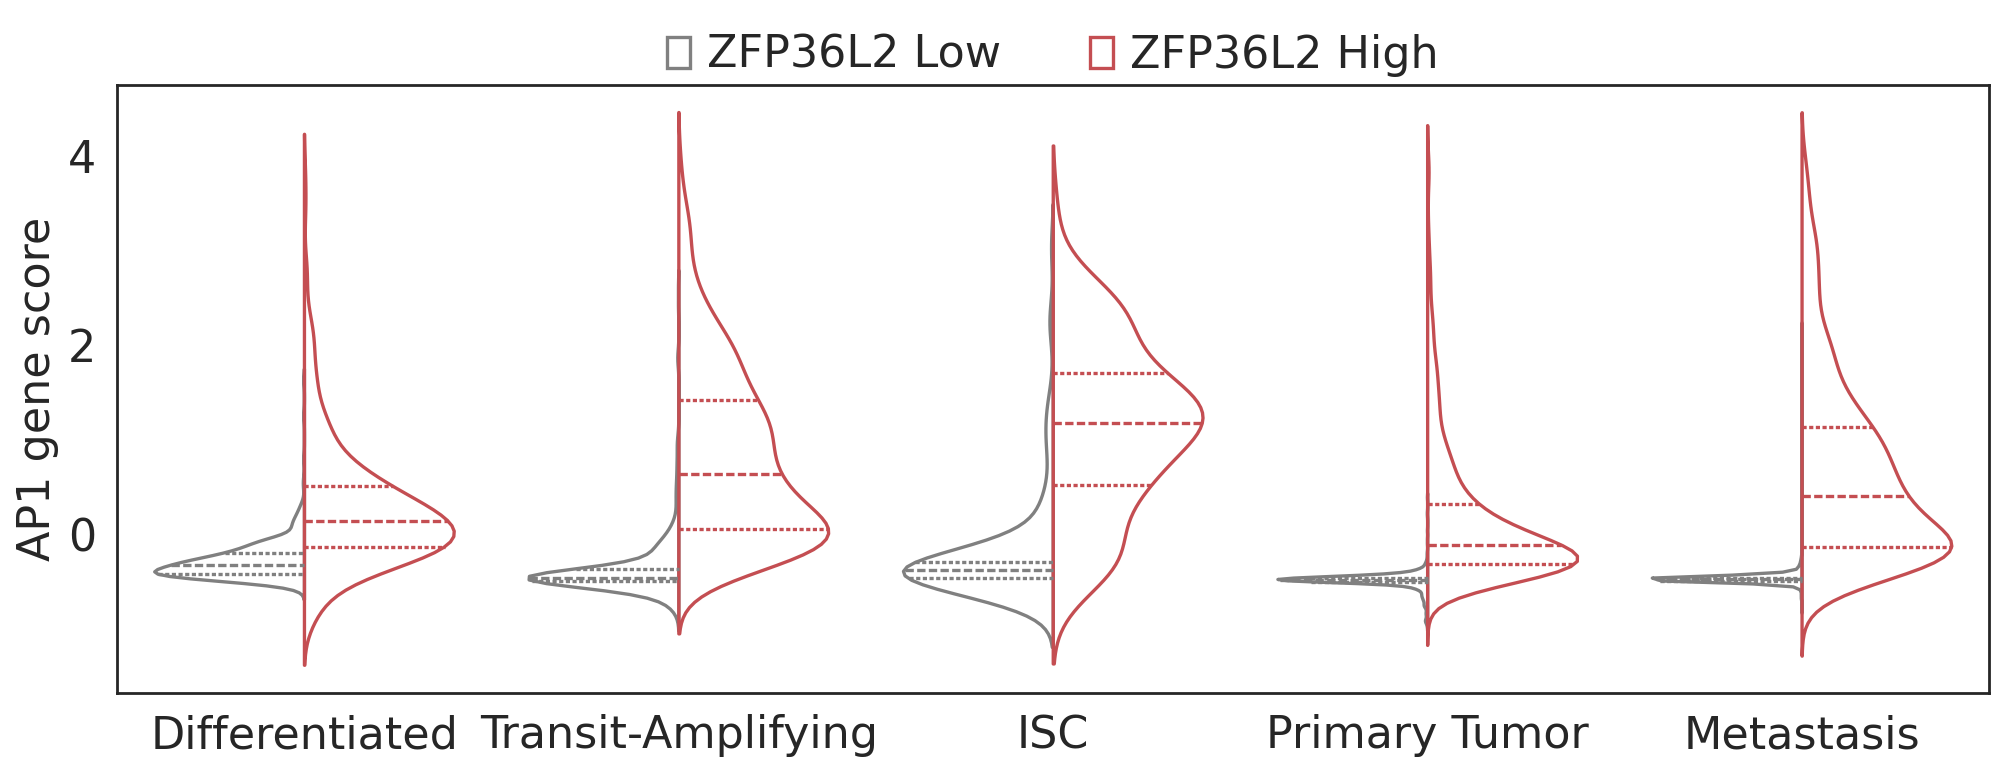

In [73]:
figures_main_data_1j = figures_main_dir / "figure_1j"
figures_main_data_1j.mkdir(parents=True, exist_ok=True)

def should_split(cell_type):
    return True

sc.set_figure_params(fontsize=30)
sns.set_theme(style="white")

x_order = ['Differentiated', 'Transit-Amplifying', 'ISC', 'Primary Tumor', 'Metastasis']

filtered_df = plot_df_AP1[
    plot_df_AP1['DEG_ZFP_expression_group'].notna() &
    (plot_df_AP1['PID_AP1'] <= 4) &
    (plot_df_AP1['PID_AP1'] >= -1)
].copy()

filtered_df['ZFP_Group'] = filtered_df['DEG_ZFP_expression_group'].apply(
    lambda x: 'ZFP36L2 High' if 'High' in x else 'ZFP36L2 Low'
)

fig, ax = plt.subplots(figsize=(15, 5))

for cell_type in x_order:
    subset = filtered_df[filtered_df['Cell Type 3'] == cell_type]
    
    split_violin = should_split(cell_type)
    
    sns.violinplot(
        data=subset, 
        x='Cell Type 3', 
        y='PID_AP1',
        hue='ZFP_Group',
        split=split_violin,  
        inner="quart", 
        fill=False, 
        palette={"ZFP36L2 Low": "gray", "ZFP36L2 High": "r"},
        hue_order=["ZFP36L2 Low", "ZFP36L2 High"],  
        ax=ax, 
        order=[cell_type],  
    )

ax.set_xlabel('')
ax.set_ylabel('AP1 gene score', fontsize=20)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=2, frameon=False, fontsize=20)

plt.savefig(figures_main_data_1j/"AP1_score_ZFP_high_low_violinplot_split.pdf", format='pdf', bbox_inches='tight')


### Statistics

In [74]:
cell_type_zfp_values = []
pid_ap1_values = []

unique_combinations = plot_df_AP1[['Cell Type 3', 'DEG_ZFP_expression_group']].drop_duplicates()

for _, row in unique_combinations.iterrows():
    cell_type = row['Cell Type 3']
    zfp_group = row['DEG_ZFP_expression_group']
    
    filtered_rows = plot_df_AP1[(plot_df_AP1['Cell Type 3'] == cell_type) & 
                            (plot_df_AP1['DEG_ZFP_expression_group'] == zfp_group)]
    
    pid_ap1_values.extend(filtered_rows['PID_AP1'].tolist())
    
    label = f"{cell_type} - {zfp_group}"
    
    cell_type_zfp_values.extend([label] * len(filtered_rows))

result_df_AP1 = pd.DataFrame({
    'Cell Type/DEG_ZFP_expression_group': cell_type_zfp_values,
    'PID_AP1': pid_ap1_values
})

In [75]:
result_df_AP1 = plot_df_AP1[['DEG_ZFP_expression_group', 'PID_AP1']].dropna()

In [76]:
group1_list_AP1 = []
group2_list_AP1 = []
p_value_list_AP1 = []
group1_pid_values = []
group2_pid_values = []

unique_combinations = result_df_AP1['DEG_ZFP_expression_group'].unique()

for group1, group2 in combinations(unique_combinations, 2):
    group1_values = result_df_AP1[result_df_AP1['DEG_ZFP_expression_group'] == group1]['PID_AP1']
    group2_values = result_df_AP1[result_df_AP1['DEG_ZFP_expression_group'] == group2]['PID_AP1']
    
    if len(group1_values) > 0 and len(group2_values) > 0:
        stat, p_value = mannwhitneyu(group1_values, group2_values)

        group1_list_AP1.append(group1)
        group2_list_AP1.append(group2)
        p_value_list_AP1.append(p_value)

        group1_pid_values.append(group1_values.mean()) 
        group2_pid_values.append(group2_values.mean())

mannwhitney_df_AP1 = pd.DataFrame({
    'Group 1': group1_list_AP1,
    'Group 2': group2_list_AP1,
    'p-value': p_value_list_AP1,
    'Group 1 Mean PID_AP1': group1_pid_values,
    'Group 2 Mean PID_AP1': group2_pid_values
})

mannwhitney_df_AP1['p-value <0.05'] = mannwhitney_df_AP1['p-value'].apply(lambda p: 'significant' if p < 0.05 else '')

bonferroni_factor = len(mannwhitney_df_AP1)
mannwhitney_df_AP1['Bonferroni correction'] = mannwhitney_df_AP1['p-value'] * bonferroni_factor
mannwhitney_df_AP1['Bonferroni correction'] = mannwhitney_df_AP1['Bonferroni correction'].clip(upper=1.0)

mannwhitney_df_AP1['q-value <0.05'] = mannwhitney_df_AP1['Bonferroni correction'].apply(lambda q: 'significant' if q < 0.05 else '')

In [77]:
mannwhitney_df_AP1.to_csv(figures_main_data_1j/"mannwhitney_AP1_gene_score_ZFP36L2_high_low.csv")